# EFW Quinquennial × Macro (WB + PWT + EFW)


## Purpose and Story Spine
This notebook builds a **quinquennial panel (1970–2020)** from `macro_panel.parquet` and delivers a presentable descriptive analysis of **Economic Freedom (EFW)** in relation to **World Bank (WB)** and **Penn World Table (PWT)** macro series. We focus on:

- **Levels**: How EFW levels differ across time, regions/continents, and income groups.
- **Changes**: Five‑year changes in EFW and macro series, including asymmetries (gains vs. losses).
- **Initial state dependence**: Do low‑EFW countries catch up? Do high‑EFW countries regress?
- **Macro correlations**: How EFW relates to macro outcomes across epochs.

No election data is used in this notebook.


In [23]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import yaml
import json
import random
import sys
from datetime import datetime
from IPython.display import display, Markdown

pd.options.mode.copy_on_write = True

%matplotlib inline


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / 'data').exists() and (p / 'notebooks').exists():
            return p
    raise ValueError('Repo root not found; expected data/ and notebooks/ in a parent directory')

ROOT = find_repo_root()

PATHS = {
    'data_processed': ROOT / 'data' / 'processed',
    'data_raw': ROOT / 'data' / 'raw',
}

NOTEBOOK_NAME = '02_efw_quinquennial_macro_presentable'
OUT_ROOT = ROOT / 'outputs'
OUT_FIG = OUT_ROOT / 'figures' / NOTEBOOK_NAME
OUT_TAB = OUT_ROOT / 'tables' / NOTEBOOK_NAME
OUT_LOG = OUT_ROOT / 'logs' / NOTEBOOK_NAME
for p in [OUT_FIG, OUT_TAB, OUT_LOG]:
    p.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})


def read_parquet_pyarrow(path: str | Path) -> pd.DataFrame:
    table = pq.read_table(str(path))
    return table.to_pandas()


def _coerce_for_parquet(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in out.columns:
        dtype = out[col].dtype
        # Interval dtype or categorical with interval categories
        if pd.api.types.is_interval_dtype(dtype):
            out[col] = out[col].astype(str)
        elif pd.api.types.is_categorical_dtype(dtype):
            try:
                if pd.api.types.is_interval_dtype(out[col].cat.categories.dtype):
                    out[col] = out[col].astype(str)
            except Exception:
                pass
    return out


def write_parquet_pyarrow(df: pd.DataFrame, path: str | Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    safe = _coerce_for_parquet(df)
    table = pa.Table.from_pandas(safe, preserve_index=False)
    pq.write_table(table, str(path))


def save_table(df: pd.DataFrame, name: str, *, index: bool = False, also_md: bool = False) -> None:
    write_parquet_pyarrow(df, OUT_TAB / f"{name}.parquet")
    df.to_csv(OUT_TAB / f"{name}.csv", index=index)
    if also_md:
        df_md = df.astype(object).where(pd.notna(df), None)
        (OUT_TAB / f"{name}.md").write_text(
            df_md.to_markdown(index=index, missingval="")
        )


def save_log(df: pd.DataFrame, name: str, *, index: bool = False) -> None:
    write_parquet_pyarrow(df, OUT_LOG / f"{name}.parquet")
    df.to_csv(OUT_LOG / f"{name}.csv", index=index)


def save_fig(name: str, fig=None) -> None:
    fig = fig or plt.gcf()
    fig.savefig(OUT_FIG / f"{name}.png", bbox_inches='tight')
    fig.savefig(OUT_FIG / f"{name}.pdf", bbox_inches='tight')


AUDIT_LOG = []


def log_df(df: pd.DataFrame, step: str, keys: list[str] | None = None, notes: str = "") -> None:
    row = {
        'step': step,
        'n_rows': int(len(df)),
        'n_cols': int(df.shape[1]),
        'n_iso3': int(df['iso3'].nunique(dropna=True)) if 'iso3' in df.columns else None,
        'notes': notes,
    }
    if keys:
        row['n_dupe_rows_on_keys'] = int(df.duplicated(subset=keys).sum())
    AUDIT_LOG.append(row)


def assert_unique(df: pd.DataFrame, keys: list[str], allow_na: bool = False) -> None:
    if not allow_na and df[keys].isna().any().any():
        raise AssertionError(f"Missing values in key columns {keys}")
    dupes = df.duplicated(subset=keys)
    if dupes.any():
        raise AssertionError(f"Duplicate rows found on keys {keys}: {int(dupes.sum())}")


def assert_in_set(df: pd.DataFrame, col: str, allowed: set[str]) -> None:
    bad = set(df[col].dropna().unique()) - set(allowed)
    if bad:
        raise AssertionError(f"Column {col} has values outside allowed set: {bad}")


def assert_bounds(df: pd.DataFrame, col: str, lo: float, hi: float, tol: float = 1e-9, allow_na: bool = True) -> None:
    s = df[col]
    if not allow_na:
        s = s.dropna()
    bad = s[(s < lo - tol) | (s > hi + tol)]
    if not bad.empty:
        raise AssertionError(f"Column {col} has {len(bad)} values outside bounds [{lo},{hi}]")


def log_merge(left: pd.DataFrame, right: pd.DataFrame, on: list[str], how: str, step: str) -> pd.DataFrame:
    merged = left.merge(right, on=on, how=how, indicator=True)
    row = {
        'step': step,
        'left_rows': int(len(left)),
        'right_rows': int(len(right)),
        'merged_rows': int(len(merged)),
        'matched_rows': int((merged['_merge'] == 'both').sum()),
        'left_only_rows': int((merged['_merge'] == 'left_only').sum()),
        'right_only_rows': int((merged['_merge'] == 'right_only').sum()),
        'on_keys': ','.join(on),
        'how': how,
    }
    AUDIT_LOG.append(row)
    return merged.drop(columns=['_merge'])


def show_table(df: pd.DataFrame, title: str | None = None, n: int | None = None) -> None:
    if title:
        print(title)
    if n is None:
        display(df)
    else:
        display(df.head(n))

# Version log
VERSIONS = {
    'python': sys.version.split()[0],
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'pyarrow': pa.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'run_timestamp': datetime.now().isoformat(timespec='seconds'),
}
with open(OUT_LOG / 'versions.json', 'w') as f:
    json.dump(VERSIONS, f, indent=2)


In [24]:
# Load macro panel (WB + PWT + EFW)
PATH_MACRO = PATHS['data_processed'] / 'macro_panel.parquet'
macro = read_parquet_pyarrow(PATH_MACRO)

# Basic normalization
macro['iso3'] = macro['iso3'].astype('string').str.upper().str.strip()
macro['year'] = pd.to_numeric(macro['year'], errors='coerce')
macro = macro[macro['iso3'].str.len() == 3]
macro = macro[macro['year'].notna()]
macro['year'] = macro['year'].astype(int)

assert_unique(macro, ['iso3','year'])
log_df(macro, 'loaded_macro_panel', keys=['iso3','year'])

# Rename EFW columns to readable names
rename_efw = {
    'efw_Summary': 'efw_total',
    'efw_Area 1': 'efw_area1',
    'efw_Area 2': 'efw_area2',
    'efw_Area 3': 'efw_area3',
    'efw_Area 4': 'efw_area4',
    'efw_Area 5': 'efw_area5',
    'efw_Standard Deviation of the 5 EFW Areas': 'efw_sd_areas',
}
macro = macro.rename(columns={k: v for k, v in rename_efw.items() if k in macro.columns})

if 'efw_total' not in macro.columns:
    raise ValueError('efw_total not found in macro_panel.parquet')

# Quinquennial years (1970–2020)
quinquennial_years = [1970,1975,1980,1985,1990,1995,2000,2005,2010,2015,2020]
panel = macro[macro['year'].isin(quinquennial_years)].copy()
assert_in_set(panel, 'year', set(quinquennial_years))

log_df(panel, 'panel_quinquennial_base', keys=['iso3','year'])
print('Panel rows (quinquennial):', len(panel))


Panel rows (quinquennial): 2387


In [25]:
# Add region/income metadata from EFW Excel
PATH_EFW = ROOT / 'efw.xlsx'
EFW_SHEET = 'EFW Panel Dataset'

meta_cols = ['ISO_Code', 'World Bank Region', 'World Bank Current Income Classification, 1990-Present']
try:
    ef_meta = pd.read_excel(PATH_EFW, sheet_name=EFW_SHEET, usecols=meta_cols)
except ImportError as e:
    raise ImportError("Reading efw.xlsx requires openpyxl. Install via `pip install openpyxl`.") from e

ef_meta = ef_meta.rename(columns={
    'ISO_Code': 'iso3',
    'World Bank Region': 'wb_region',
    'World Bank Current Income Classification, 1990-Present': 'wb_income'
})
ef_meta['iso3'] = ef_meta['iso3'].astype(str).str.upper().str.strip()

# Keep the most common non-null metadata per iso3
meta_agg = (ef_meta
    .dropna(subset=['iso3'])
    .groupby('iso3')
    .agg({
        'wb_region': lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else pd.NA,
        'wb_income': lambda s: s.dropna().mode().iloc[0] if not s.dropna().empty else pd.NA,
    })
    .reset_index()
)

panel = panel.merge(meta_agg, on='iso3', how='left')

# Map World Bank regions to continents (coarse groups)
region_to_continent = {
    'Sub-Saharan Africa': 'Africa',
    'Middle East & North Africa': 'Middle East & North Africa',
    'South Asia': 'Asia',
    'East Asia & Pacific': 'Asia & Pacific',
    'Europe & North America': 'Europe & North America',
    'Latin America & the Caribbean': 'Americas',
    'North America': 'North America',
}
panel['continent'] = panel['wb_region'].map(region_to_continent).fillna('Other/Unknown')

# Epochs
bins = [1969, 1984, 1999, 2009, 2020]
labels = ['1970-84','1985-99','2000-09','2010-20']
panel['epoch'] = pd.cut(panel['year'], bins=bins, labels=labels)

log_df(panel, 'panel_with_metadata', keys=['iso3','year'])


In [26]:
# Derived changes (5-year) and helper lists
panel = panel.sort_values(['iso3','year'])

panel['efw_total_lag5'] = panel.groupby('iso3')['efw_total'].shift(1)
panel['efw_delta_5y'] = panel['efw_total'] - panel['efw_total_lag5']

# Macro change proxies (5-year differences on selected series)
macro_change_vars = [
    'macro_gdp_pc_real_log',
    'macro_gov_cons_gdp',
    'macro_trade_gdp',
    'macro_inflation_cpi',
    'macro_credit_private_gdp',
]
for v in macro_change_vars:
    if v in panel.columns:
        panel[f'{v}_delta_5y'] = panel.groupby('iso3')[v].diff()

# Candidate macro & PWT series for comparisons
macro_vars = [v for v in [
    'macro_gdp_pc_real_log',
    'macro_gdp_growth',
    'macro_inflation_cpi',
    'macro_trade_gdp',
    'macro_gov_cons_gdp',
    'macro_inv_gdp',
    'macro_credit_private_gdp',
    'macro_debt_gdp',
    'macro_money_broad_gdp',
    'macro_natres_rents_gdp',
] if v in panel.columns]

pwt_vars = [v for v in [
    'pwt_cgdpo',
    'pwt_ctfp',
    'pwt_rtfpna',
    'pwt_ck',
    'pwt_csh_i',
    'pwt_avh',
] if v in panel.columns]

print('Macro vars:', macro_vars)
print('PWT vars:', pwt_vars)


Macro vars: ['macro_gdp_pc_real_log', 'macro_gdp_growth', 'macro_inflation_cpi', 'macro_trade_gdp', 'macro_gov_cons_gdp', 'macro_inv_gdp', 'macro_credit_private_gdp', 'macro_debt_gdp', 'macro_money_broad_gdp', 'macro_natres_rents_gdp']
PWT vars: ['pwt_cgdpo', 'pwt_ctfp', 'pwt_rtfpna', 'pwt_ck', 'pwt_csh_i', 'pwt_avh']


EFW Missingness (quinquennial)


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


,var,missing_share
2,efw_area2,0.285714
5,efw_area5,0.341433
1,efw_area1,0.345622
3,efw_area3,0.373272
0,efw_total,0.386259
6,efw_sd_areas,0.386259
7,efw_total_lag5,0.454964
8,efw_delta_5y,0.454964
4,efw_area4,0.458316


Macro Missingness (best 10)


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


,var,missing_share
0,macro_gdp_pc_real_log,0.150398
1,macro_gdp_growth,0.167155
9,macro_natres_rents_gdp,0.183075
3,macro_trade_gdp,0.323419
2,macro_inflation_cpi,0.329703
4,macro_gov_cons_gdp,0.348974
8,macro_money_broad_gdp,0.375786
5,macro_inv_gdp,0.377880
6,macro_credit_private_gdp,0.434018
7,macro_debt_gdp,0.862170


Macro Missingness (worst 10)


,var,missing_share
0,macro_gdp_pc_real_log,0.150398
1,macro_gdp_growth,0.167155
9,macro_natres_rents_gdp,0.183075
3,macro_trade_gdp,0.323419
2,macro_inflation_cpi,0.329703
4,macro_gov_cons_gdp,0.348974
8,macro_money_broad_gdp,0.375786
5,macro_inv_gdp,0.377880
6,macro_credit_private_gdp,0.434018
7,macro_debt_gdp,0.862170


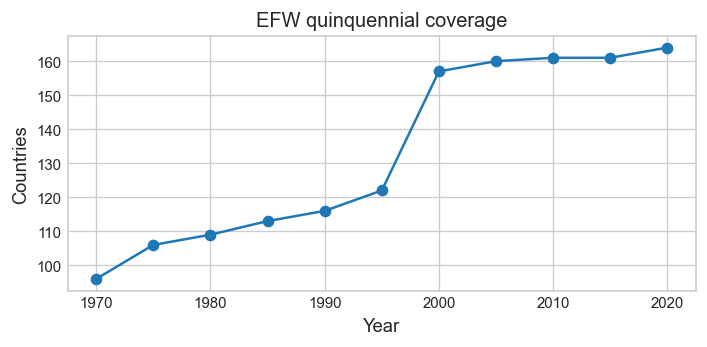

In [27]:
# Coverage diagnostics (quinquennial)

def missingness_by_year(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = []
    for y, g in df.groupby('year'):
        row = {'year': int(y)}
        for c in cols:
            row[c] = g[c].isna().mean()
        out.append(row)
    return pd.DataFrame(out).sort_values('year')

# EFW coverage
efw_vars = [c for c in panel.columns if c.startswith('efw_')]
miss_efw = panel[efw_vars].isna().mean().reset_index()
miss_efw.columns = ['var','missing_share']
miss_efw = miss_efw.sort_values('missing_share')
save_table(miss_efw, 'efw_missingness_quinquennial', also_md=True)
show_table(miss_efw, title='EFW Missingness (quinquennial)')

# Macro coverage
miss_macro = panel[macro_vars].isna().mean().reset_index()
miss_macro.columns = ['var','missing_share']
miss_macro = miss_macro.sort_values('missing_share')
save_table(miss_macro, 'macro_missingness_quinquennial', also_md=True)
show_table(miss_macro.head(10), title='Macro Missingness (best 10)')
show_table(miss_macro.tail(10), title='Macro Missingness (worst 10)')

# Time coverage plot for EFW total
cov_year = (panel
    .groupby('year')['efw_total']
    .apply(lambda s: s.notna().sum())
    .reset_index(name='n_countries')
)

plt.figure(figsize=(6,3))
plt.plot(cov_year['year'], cov_year['n_countries'], marker='o')
plt.title('EFW quinquennial coverage')
plt.xlabel('Year')
plt.ylabel('Countries')
plt.tight_layout()
save_fig('efw_year_coverage')
plt.show()


EFW levels by epoch


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/909158968.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('epoch')['efw_total']
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:74: DeprecationWarning

,epoch,mean,median,count
0,1970-84,5.458384,5.345370,311
1,1985-99,5.798712,5.734114,351
2,2000-09,6.414809,6.399104,317
3,2010-20,6.594124,6.649886,486


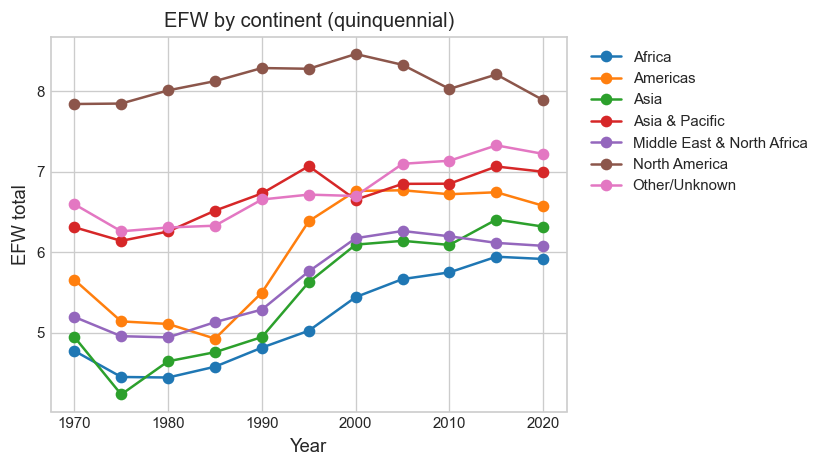

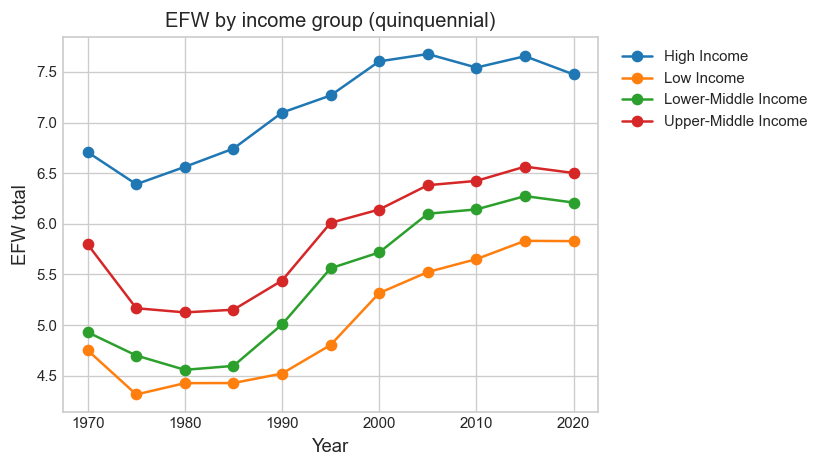

In [28]:
# EFW levels by epoch, continent, income group

# Overall epoch summary
epoch_summary = (panel
    .groupby('epoch')['efw_total']
    .agg(['mean','median','count'])
    .reset_index()
)
save_table(epoch_summary, 'efw_epoch_summary', also_md=True)
show_table(epoch_summary, title='EFW levels by epoch')

# By continent
cont_summary = (panel
    .groupby(['continent','year'])['efw_total']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
for cont, g in cont_summary.groupby('continent'):
    plt.plot(g['year'], g['efw_total'], marker='o', label=cont)
plt.title('EFW by continent (quinquennial)')
plt.xlabel('Year')
plt.ylabel('EFW total')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
save_fig('efw_by_continent')
plt.show()

# By income group
income_summary = (panel
    .groupby(['wb_income','year'])['efw_total']
    .mean()
    .reset_index()
)

plt.figure(figsize=(7,4))
for inc, g in income_summary.groupby('wb_income'):
    plt.plot(g['year'], g['efw_total'], marker='o', label=inc)
plt.title('EFW by income group (quinquennial)')
plt.xlabel('Year')
plt.ylabel('EFW total')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
save_fig('efw_by_income_group')
plt.show()


## Magnitudes and Distributions


EFW 5y change – overall distribution


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


,mean,median,std,p10,p25,p75,p90,share_pos,share_neg,share_large_abs1,n
0,0.126221,0.084989,0.502483,-0.399533,-0.149595,0.377233,0.76745,0.594158,0.40123,0.065334,1301.0


EFW 5y change – by epoch


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/3256627368.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_epoch = change.groupby('epoch')['efw_delta_5y'].apply(dist_stats).reset_index()
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/

,epoch,level_1,efw_delta_5y
0,1970-84,mean,-0.121815
1,1970-84,median,-0.056802
2,1970-84,std,0.476013
3,1970-84,p10,-0.744612
4,1970-84,p25,-0.396895
5,1970-84,p75,0.164662
6,1970-84,p90,0.404883
7,1970-84,share_pos,0.420792
8,1970-84,share_neg,0.569307
9,1970-84,share_large_abs1,0.059406


EFW 5y change – by continent


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


,continent,level_1,efw_delta_5y
0,Africa,mean,0.128036
1,Africa,median,0.127867
2,Africa,std,0.524479
3,Africa,p10,-0.411066
4,Africa,p25,-0.166209
...,...,...,...
72,Other/Unknown,p90,0.773995
73,Other/Unknown,share_pos,0.642229
74,Other/Unknown,share_neg,0.348974
75,Other/Unknown,share_large_abs1,0.055718


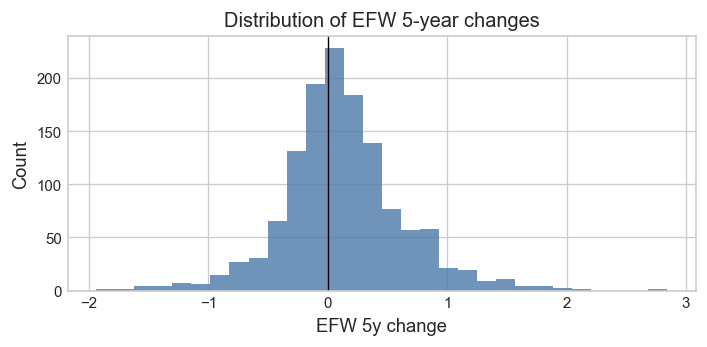

/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/3256627368.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for ax, (ep, g) in zip(axes, change.groupby('epoch')):


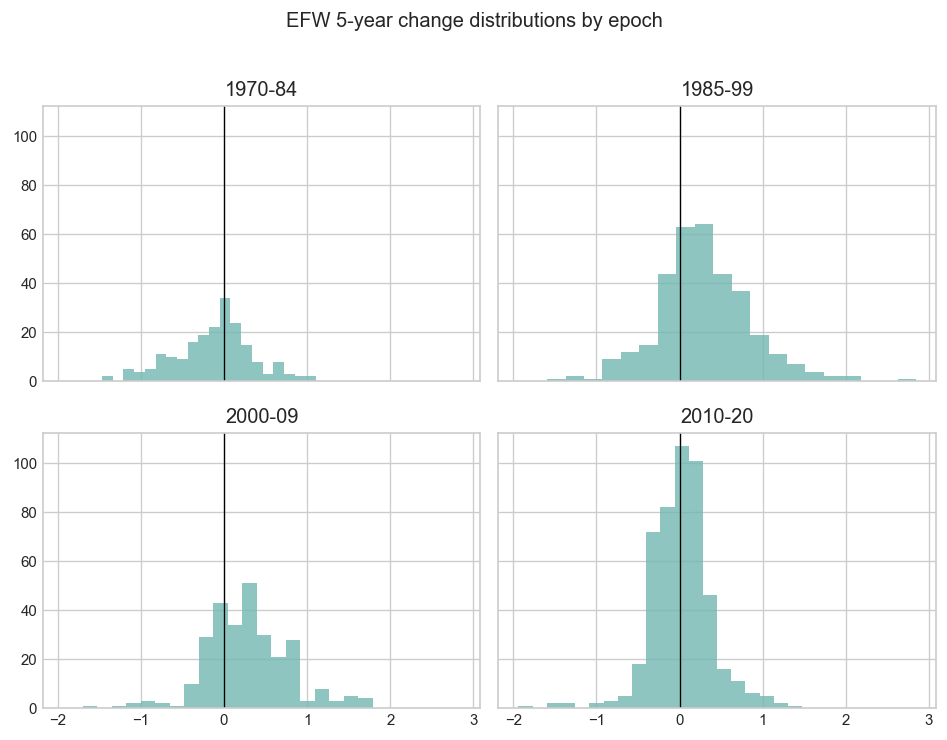

In [29]:
# Magnitudes of EFW 5-year changes
change = panel.dropna(subset=['efw_delta_5y']).copy()


def dist_stats(s: pd.Series) -> pd.Series:
    return pd.Series({
        'mean': s.mean(),
        'median': s.median(),
        'std': s.std(),
        'p10': s.quantile(0.10),
        'p25': s.quantile(0.25),
        'p75': s.quantile(0.75),
        'p90': s.quantile(0.90),
        'share_pos': (s > 0).mean(),
        'share_neg': (s < 0).mean(),
        'share_large_abs1': (s.abs() >= 1).mean(),
        'n': s.notna().sum(),
    })

# Overall distribution
overall_stats = dist_stats(change['efw_delta_5y']).to_frame().T
save_table(overall_stats, 'efw_change_overall_stats', also_md=True)
show_table(overall_stats, title='EFW 5y change – overall distribution')

# By epoch
by_epoch = change.groupby('epoch')['efw_delta_5y'].apply(dist_stats).reset_index()
save_table(by_epoch, 'efw_change_by_epoch', also_md=True)
show_table(by_epoch, title='EFW 5y change – by epoch')

# By continent
by_cont = change.groupby('continent')['efw_delta_5y'].apply(dist_stats).reset_index()
save_table(by_cont, 'efw_change_by_continent', also_md=True)
show_table(by_cont, title='EFW 5y change – by continent')

# Histogram overall
plt.figure(figsize=(6,3))
plt.hist(change['efw_delta_5y'].dropna(), bins=30, color='#4C78A8', alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Distribution of EFW 5-year changes')
plt.xlabel('EFW 5y change')
plt.ylabel('Count')
plt.tight_layout()
save_fig('efw_change_hist_overall')
plt.show()

# Histogram by epoch (small multiples)
fig, axes = plt.subplots(2, 2, figsize=(8,6), sharex=True, sharey=True)
axes = axes.flatten()
for ax, (ep, g) in zip(axes, change.groupby('epoch')):
    ax.hist(g['efw_delta_5y'].dropna(), bins=20, color='#72B7B2', alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(str(ep))
plt.suptitle('EFW 5-year change distributions by epoch', y=1.02)
plt.tight_layout()
save_fig('efw_change_hist_by_epoch')
plt.show()


## Asymmetries and Initial-State Dependence


EFW changes: increases vs decreases


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


,efw_direction,mean,median,count,mean_abs
0,EFW_down,-0.309719,-0.219697,522,0.309719
1,EFW_up,0.421587,0.318442,773,0.421587
2,No_change,0.000000,0.000000,6,0.000000


EFW change by initial level (quintiles)


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/2492424574.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_summary = state.groupby('initial_bin')['efw_delta_5y'].agg(['mean','median','count']).reset_index()
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):
/var/folders/w9/87d44l6n0s

,initial_bin,mean,median,count
0,"(2.22, 4.924]",0.319807,0.324085,261
1,"(4.924, 5.734]",0.174335,0.191995,260
2,"(5.734, 6.44]",0.098149,0.079866,260
3,"(6.44, 7.318]",0.059979,0.069329,260
4,"(7.318, 9.199]",-0.021911,-0.004690,260


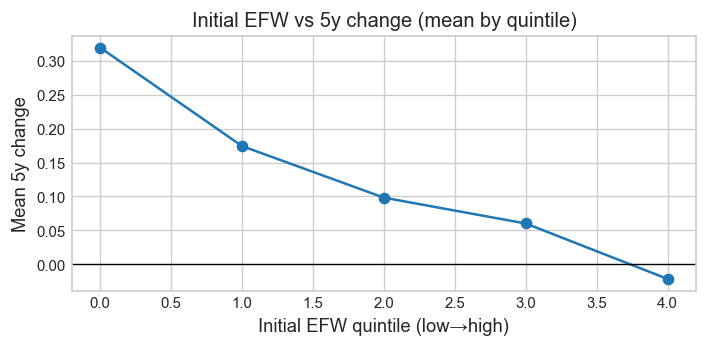

/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


Macro change diff (up - down): bottom 10


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


efw_direction,var,EFW_down,EFW_up,mean_diff_up_minus_down
4,macro_inflation_cpi_delta_5y,30.398351,-21.652288,-52.050639
3,macro_gov_cons_gdp_delta_5y,1.035616,-0.116345,-1.151960
2,macro_gdp_pc_real_log_delta_5y,0.052540,0.102204,0.049664
1,macro_credit_private_gdp_delta_5y,3.867692,4.160620,0.292927
5,macro_trade_gdp_delta_5y,1.637091,2.189685,0.552594
0,efw_delta_5y,-0.309719,0.421587,0.731306


Macro change diff (up - down): top 10


efw_direction,var,EFW_down,EFW_up,mean_diff_up_minus_down
4,macro_inflation_cpi_delta_5y,30.398351,-21.652288,-52.050639
3,macro_gov_cons_gdp_delta_5y,1.035616,-0.116345,-1.151960
2,macro_gdp_pc_real_log_delta_5y,0.052540,0.102204,0.049664
1,macro_credit_private_gdp_delta_5y,3.867692,4.160620,0.292927
5,macro_trade_gdp_delta_5y,1.637091,2.189685,0.552594
0,efw_delta_5y,-0.309719,0.421587,0.731306


In [30]:
# Asymmetry: EFW increases vs decreases
asym = change.copy()
asym['efw_direction'] = np.where(asym['efw_delta_5y'] > 0, 'EFW_up', np.where(asym['efw_delta_5y'] < 0, 'EFW_down', 'No_change'))

asym_stats = (asym
    .groupby('efw_direction')['efw_delta_5y']
    .agg(['mean','median','count'])
    .reset_index()
)
# add mean absolute change
mean_abs = asym.groupby('efw_direction')['efw_delta_5y'].apply(lambda s: s.abs().mean()).reset_index()
mean_abs = mean_abs.rename(columns={'efw_delta_5y': 'mean_abs'})
asym_stats = asym_stats.merge(mean_abs, on='efw_direction', how='left')

save_table(asym_stats, 'efw_change_asymmetry', also_md=True)
show_table(asym_stats, title='EFW changes: increases vs decreases')

# Initial state dependence (quintiles of lagged EFW)
state = panel.dropna(subset=['efw_total_lag5','efw_delta_5y']).copy()
if len(state) > 0:
    state['initial_bin'] = pd.qcut(state['efw_total_lag5'], q=5, duplicates='drop')
    bin_summary = state.groupby('initial_bin')['efw_delta_5y'].agg(['mean','median','count']).reset_index()
    save_table(bin_summary, 'efw_change_by_initial_bin', also_md=True)
    show_table(bin_summary, title='EFW change by initial level (quintiles)')

    plt.figure(figsize=(6,3))
    plt.plot(range(len(bin_summary)), bin_summary['mean'], marker='o')
    plt.axhline(0, color='black', linewidth=0.8)
    plt.title('Initial EFW vs 5y change (mean by quintile)')
    plt.xlabel('Initial EFW quintile (low→high)')
    plt.ylabel('Mean 5y change')
    plt.tight_layout()
    save_fig('efw_initial_state_dependence')
    plt.show()

# Macro asymmetry conditional on EFW direction
macro_delta_cols = [c for c in panel.columns if c.endswith('_delta_5y')]
rows = []
for v in macro_delta_cols:
    for d in ['EFW_up','EFW_down']:
        sub = asym[asym['efw_direction'] == d][v].dropna()
        if len(sub) == 0:
            continue
        rows.append({'var': v, 'efw_direction': d, 'mean': sub.mean(), 'median': sub.median(), 'n': len(sub)})

asym_macro = pd.DataFrame(rows)
if not asym_macro.empty:
    # difference in means (up - down)
    pivot = asym_macro.pivot(index='var', columns='efw_direction', values='mean')
    pivot['mean_diff_up_minus_down'] = pivot.get('EFW_up', np.nan) - pivot.get('EFW_down', np.nan)
    pivot = pivot.reset_index()
    save_table(asym_macro, 'macro_changes_by_efw_direction', also_md=True)
    save_table(pivot, 'macro_changes_diff_up_minus_down', also_md=True)
    show_table(pivot.sort_values('mean_diff_up_minus_down').head(10), title='Macro change diff (up - down): bottom 10')
    show_table(pivot.sort_values('mean_diff_up_minus_down').tail(10), title='Macro change diff (up - down): top 10')


## Mobility and Transition Matrices


EFW transition probabilities (rows sum to 1)


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Us

efw_quintile,1,2,3,4,5
efw_quintile_lag,,,,,
1.0,0.774436,0.191729,0.033835,0.000000,0.000000
2.0,0.174419,0.542636,0.240310,0.042636,0.000000
3.0,0.023256,0.217054,0.515504,0.240310,0.003876
4.0,0.000000,0.015504,0.197674,0.643411,0.143411
5.0,0.000000,0.000000,0.007663,0.095785,0.896552


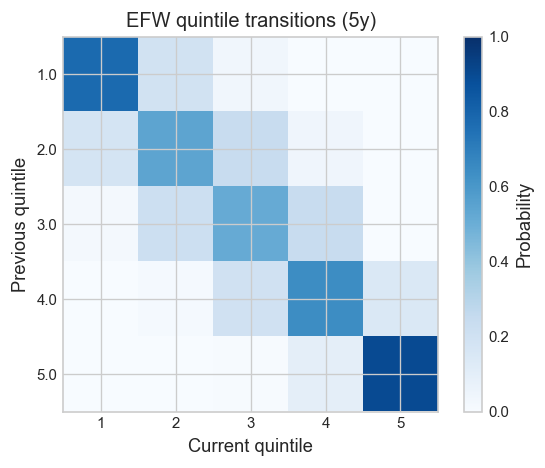

In [31]:
# Transition matrix of EFW quintiles (within-year)
trans_df = panel.dropna(subset=['efw_total']).copy()

# Assign quintiles within each year
trans_df['efw_quintile'] = trans_df.groupby('year')['efw_total'].transform(
    lambda s: pd.qcut(s, q=5, labels=False, duplicates='drop')
)
trans_df['efw_quintile'] = trans_df['efw_quintile'] + 1  # 1-5

# Lagged quintile by country
trans_df = trans_df.sort_values(['iso3','year'])
trans_df['efw_quintile_lag'] = trans_df.groupby('iso3')['efw_quintile'].shift(1)

trans = (trans_df
    .dropna(subset=['efw_quintile_lag','efw_quintile'])
    .groupby(['efw_quintile_lag','efw_quintile'])
    .size()
    .unstack(fill_value=0)
)

trans_prob = trans.div(trans.sum(axis=1), axis=0)

save_table(trans, 'efw_transition_counts', also_md=True)
save_table(trans_prob, 'efw_transition_probs', also_md=True)
show_table(trans_prob, title='EFW transition probabilities (rows sum to 1)')

# Heatmap
plt.figure(figsize=(5,4))
plt.imshow(trans_prob.values, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(label='Probability')
plt.xticks(range(len(trans_prob.columns)), trans_prob.columns)
plt.yticks(range(len(trans_prob.index)), trans_prob.index)
plt.xlabel('Current quintile')
plt.ylabel('Previous quintile')
plt.title('EFW quintile transitions (5y)')
plt.tight_layout()
save_fig('efw_transition_heatmap')
plt.show()


## Logarithms and Percent-Change Analysis


EFW change correlations: level vs log vs percent


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/790210477.py:22: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  panel[f'{level_var}_pct_5y'] = panel.groupby('iso3')[level_var].pct_change()
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/790210477.py:22: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  panel[f'{level_var}_pct_5y'] = panel.groupby('iso3')[level_var].pct_change()
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/790210477.py:22: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and

,var,corr_level_diff,corr_log_diff,corr_pct_change,n
0,gdp_pc_real,0.064415,0.181029,0.174898,1287
3,pwt_cgdpo,NaN,0.158306,0.150731,1282
7,pwt_cgdpe,NaN,0.142832,0.133036,1282
5,pwt_ccon,NaN,0.142406,0.133597,1282
1,pop,0.006756,-0.064575,-0.064464,1301
2,exrate_lcu_per_usd,-0.027348,0.061139,0.039388,1280
6,pwt_cn,NaN,0.032428,0.040729,1272
4,pwt_ck,NaN,0.017507,0.036082,1056


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/790210477.py:100: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = tmp.groupby('bin')['efw_delta_5y'].mean().reset_index()


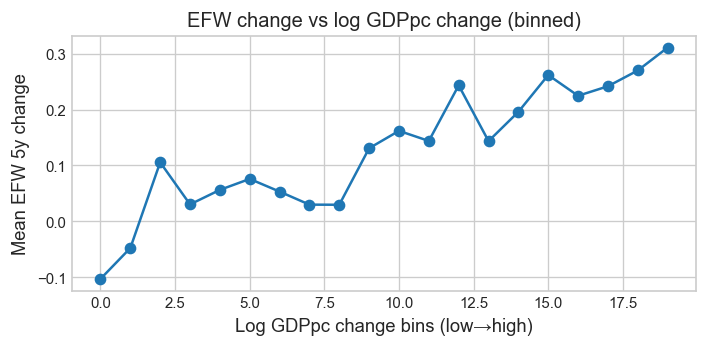

/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:74: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(out[col].cat.categories.dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in

In [32]:
# Log/percent-change analysis

# Helper for safe log

def safe_log(s: pd.Series) -> pd.Series:
    return np.log(s.where(s > 0))

log_pairs = [
    ('gdp_pc_real', 'macro_gdp_pc_real_log'),
    ('pop', 'macro_pop_log'),
    ('exrate_lcu_per_usd', 'macro_exrate_lcu_per_usd_log'),
]

# Add PWT level variables for log analysis
pwt_level_vars = [v for v in ['pwt_cgdpo','pwt_ck','pwt_ccon','pwt_cn','pwt_cgdpe'] if v in panel.columns]

results = []

# WDI level + log pairs
for level_var, log_var in log_pairs:
    if level_var in panel.columns:
        panel[f'{level_var}_pct_5y'] = panel.groupby('iso3')[level_var].pct_change()
        level_diff = panel.groupby('iso3')[level_var].diff()
        pct = panel[f'{level_var}_pct_5y']
    else:
        level_diff = None
        pct = None

    if log_var in panel.columns:
        panel[f'{log_var}_chg_5y'] = panel.groupby('iso3')[log_var].diff()
        log_diff = panel[f'{log_var}_chg_5y']
    elif level_var in panel.columns:
        panel[f'log_{level_var}'] = safe_log(panel[level_var])
        panel[f'log_{level_var}_chg_5y'] = panel.groupby('iso3')[f'log_{level_var}'].diff()
        log_diff = panel[f'log_{level_var}_chg_5y']
    else:
        log_diff = None

    # Correlations with EFW change
    if log_diff is not None:
        sub = panel[['efw_delta_5y']].copy()
        sub['log_diff'] = log_diff
        corr_log = sub.dropna().corr().iloc[0,1] if len(sub.dropna()) > 3 else np.nan
        n_log = len(sub.dropna())
    else:
        corr_log = np.nan
        n_log = 0

    if level_diff is not None:
        sub = panel[['efw_delta_5y']].copy()
        sub['level_diff'] = level_diff
        corr_level = sub.dropna().corr().iloc[0,1] if len(sub.dropna()) > 3 else np.nan
    else:
        corr_level = np.nan

    if pct is not None:
        sub = panel[['efw_delta_5y']].copy()
        sub['pct'] = pct
        corr_pct = sub.dropna().corr().iloc[0,1] if len(sub.dropna()) > 3 else np.nan
    else:
        corr_pct = np.nan

    results.append({
        'var': level_var if level_var in panel.columns else log_var,
        'corr_level_diff': corr_level,
        'corr_log_diff': corr_log,
        'corr_pct_change': corr_pct,
        'n': n_log,
    })

# PWT level variables (log + pct only)
for v in pwt_level_vars:
    panel[f'{v}_pct_5y'] = panel.groupby('iso3')[v].pct_change()
    panel[f'log_{v}'] = safe_log(panel[v])
    panel[f'log_{v}_chg_5y'] = panel.groupby('iso3')[f'log_{v}'].diff()

    sub_log = panel[['efw_delta_5y', f'log_{v}_chg_5y']].dropna()
    corr_log = sub_log.corr().iloc[0,1] if len(sub_log) > 3 else np.nan

    sub_pct = panel[['efw_delta_5y', f'{v}_pct_5y']].dropna()
    corr_pct = sub_pct.corr().iloc[0,1] if len(sub_pct) > 3 else np.nan

    results.append({
        'var': v,
        'corr_level_diff': np.nan,
        'corr_log_diff': corr_log,
        'corr_pct_change': corr_pct,
        'n': len(sub_log),
    })

corr_changes = pd.DataFrame(results).sort_values('corr_log_diff', key=lambda s: s.abs(), ascending=False)
save_table(corr_changes, 'efw_log_pct_change_correlations', also_md=True)
show_table(corr_changes, title='EFW change correlations: level vs log vs percent')

# Example binned scatter: EFW change vs log GDP per capita change
if 'macro_gdp_pc_real_log_chg_5y' in panel.columns:
    tmp = panel[['efw_delta_5y','macro_gdp_pc_real_log_chg_5y']].dropna()
    if len(tmp) > 0:
        tmp['bin'] = pd.qcut(tmp['macro_gdp_pc_real_log_chg_5y'], q=20, duplicates='drop')
        binned = tmp.groupby('bin')['efw_delta_5y'].mean().reset_index()
        plt.figure(figsize=(6,3))
        plt.plot(range(len(binned)), binned['efw_delta_5y'], marker='o')
        plt.title('EFW change vs log GDPpc change (binned)')
        plt.xlabel('Log GDPpc change bins (low→high)')
        plt.ylabel('Mean EFW 5y change')
        plt.tight_layout()
        save_fig('efw_vs_log_gdppc_binned')
        plt.show()
        save_table(binned, 'efw_vs_log_gdppc_binned', also_md=True)


## Within‑ vs Between‑Country Correlations


In [33]:
# Within- vs between-country correlation comparison

def within_between_corr(df: pd.DataFrame, x: str, y: str) -> dict:
    sub = df[[x, y, 'iso3']].dropna().copy()
    if len(sub) < 10:
        return {'corr_within': np.nan, 'corr_between': np.nan, 'n': len(sub)}

    # Within (demeaned by country)
    sub[x + '_w'] = sub[x] - sub.groupby('iso3')[x].transform('mean')
    sub[y + '_w'] = sub[y] - sub.groupby('iso3')[y].transform('mean')
    corr_within = sub[[x + '_w', y + '_w']].corr().iloc[0,1]

    # Between (country means)
    means = sub.groupby('iso3')[[x, y]].mean()
    corr_between = means.corr().iloc[0,1]

    return {'corr_within': corr_within, 'corr_between': corr_between, 'n': len(sub)}

rows = []
for v in macro_vars + pwt_vars:
    stats = within_between_corr(panel, 'efw_total', v)
    rows.append({'var': v, **stats})

wb_within_between = pd.DataFrame(rows)
save_table(wb_within_between, 'efw_within_between_corr', also_md=True)
show_table(wb_within_between, title='Within vs Between correlation: EFW vs macro/PWT')


Within vs Between correlation: EFW vs macro/PWT


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


,var,corr_within,corr_between,n
0,macro_gdp_pc_real_log,0.530764,0.735060,1451
1,macro_gdp_growth,-0.003756,-0.077237,1443
2,macro_inflation_cpi,-0.126427,-0.166336,1321
3,macro_trade_gdp,0.199193,0.418215,1300
4,macro_gov_cons_gdp,0.003490,0.167250,1294
5,macro_inv_gdp,0.121504,0.192105,1250
6,macro_credit_private_gdp,0.326218,0.721139,1086
7,macro_debt_gdp,-0.396402,-0.290224,289
8,macro_money_broad_gdp,0.078124,0.007957,1204
9,macro_natres_rents_gdp,-0.135872,-0.365459,1427


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/2788812874.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for epoch, g in panel.groupby('epoch'):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):


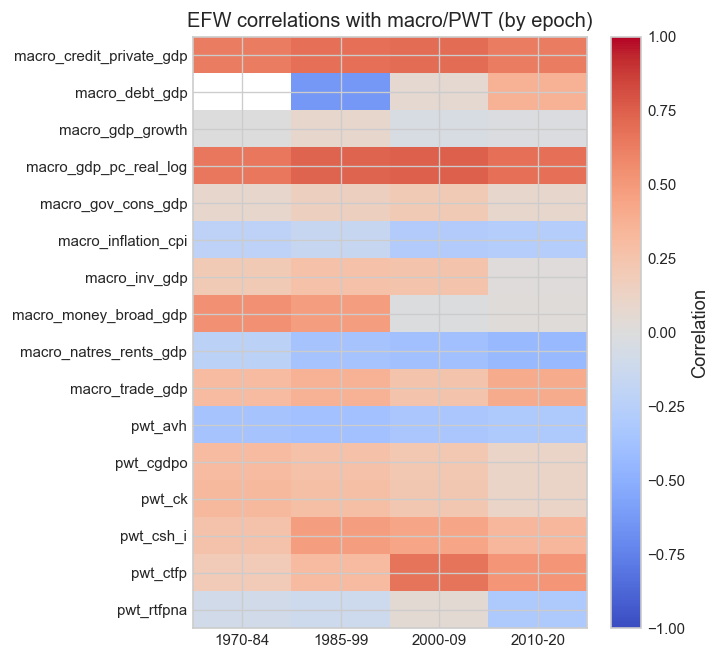

In [34]:
# EFW correlations with macro/PWT by epoch

corr_vars = ['efw_total'] + macro_vars + pwt_vars

rows = []
for epoch, g in panel.groupby('epoch'):
    for var in macro_vars + pwt_vars:
        sub = g[['efw_total', var]].dropna()
        if len(sub) >= 30:
            rows.append({'epoch': epoch, 'var': var, 'corr': sub['efw_total'].corr(sub[var]), 'n': len(sub)})

corr_df = pd.DataFrame(rows)
if not corr_df.empty:
    corr_pivot = corr_df.pivot(index='var', columns='epoch', values='corr')
    save_table(corr_df, 'efw_macro_corr_by_epoch', also_md=True)

    # simple heatmap
    plt.figure(figsize=(6, max(3, 0.35 * len(corr_pivot))))
    plt.imshow(corr_pivot.values, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.yticks(range(len(corr_pivot.index)), corr_pivot.index)
    plt.xticks(range(len(corr_pivot.columns)), corr_pivot.columns)
    plt.title('EFW correlations with macro/PWT (by epoch)')
    plt.tight_layout()
    save_fig('efw_macro_corr_by_epoch')
    plt.show()


In [35]:
# Save quinquennial panel and audit log
out_path = PATHS['data_processed'] / 'panel_efw_quinquennial_macro.parquet'
write_parquet_pyarrow(panel, out_path)
print('wrote', out_path)

if AUDIT_LOG:
    audit_df = pd.DataFrame(AUDIT_LOG)
    save_log(audit_df, 'audit_log')
    show_table(audit_df, title='Audit Log')


wrote /Users/gabrielsaco/Documents/GitHub/economic-freedom/data/processed/panel_efw_quinquennial_macro.parquet
Audit Log


/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:70: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:72: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dtype):
/var/folders/w9/87d44l6n0s9dznd5xl5dsjnm0000gn/T/ipykernel_54891/1277422076.py:74: DeprecationWarning: is_interval_dtype is deprecated and will be removed in a future version. Use `isinstance(dtype, pd.IntervalDtype)` instead
  if pd.api.types.is_interval_dtype(out[col].cat.categories.dtype):


,step,n_rows,n_cols,n_iso3,notes,n_dupe_rows_on_keys
0,loaded_macro_panel,11718,74,217,,0
1,panel_quinquennial_base,2387,74,217,,0
2,panel_with_metadata,2387,78,217,,0
